In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load
df = pd.read_csv("../data/ecommerce.csv")
print(df.head())

  Customer_ID  Age  Gender       City Device_Type  Session_Duration  \
0      C00001   25    Male       Pune      Laptop                12   
1      C00002   45    Male  Bangalore      Mobile                11   
2      C00003   46  Female    Kolkata      Mobile                29   
3      C00004   31  Female  Bangalore      Mobile                17   
4      C00005   47    Male    Chennai      Mobile                22   

   Pages_Viewed Product_Category  Price  Discount  Purchase_History  \
0             5          Fashion   4016         5                 9   
1             5      Electronics  26390        10                 9   
2            14          Fashion   3859        20                 6   
3             3             Home   4317        25                 5   
4             6             Home   3075        30                 2   

   Time_Spent_on_Product Payment_Method  Cart_Value Purchased  
0                      4     Debit Card        3815        No  
1                 

          Model  Accuracy  Precision  Recall   F1  AUC
0  RandomForest       1.0        1.0     1.0  1.0  1.0


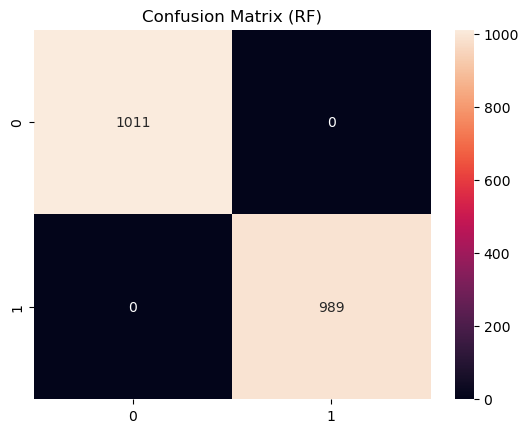

In [7]:
df.columns = df.columns.str.strip().str.lower()
# Convert target
df["purchased"] = df["purchased"].map({"Yes": 1, "No": 0})

# Drop ID column
df = df.drop(columns=["customer_id"], errors="ignore")
# Drop missing values
df = df.dropna()

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)
# Define features and target
y = df["purchased"]
X = df.drop(columns=["purchased"])

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
# Import all required metrics functions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd  # Also import pandas if not already imported
import seaborn as sns  # Import seaborn for heatmap
import matplotlib.pyplot as plt  # Import matplotlib for plotting

# Initialize models dictionary if not already defined
models = {}
models["RandomForest"] = RandomForestClassifier()

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ])

df_res = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
print(df_res)

df_res.to_csv("rq2_table.csv", index=False)

# Confusion Matrix (Random Forest)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (RF)")
plt.savefig("rq2_confusion.pdf")
plt.show()